# Final test evaluation — RadioML 2016.10A

This notebook performs the final evaluation of the frozen AMC model.

Frozen configuration:

- Random Forest classifier
- 29 features:
  - 28 baseline handcrafted features
  - circular_moment_4
- n_estimators = 200
- max_depth = 20
- min_samples_leaf = 2
- random_state = 42

Train and validation are combined for final training.

The test set is evaluated once.
No model, feature or hyperparameter changes are allowed after test evaluation.

In [22]:
from pathlib import Path
import pickle
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [2]:
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

sys.path.append(str(SRC_DIR))

from rfml.features import (
    build_feature_table,
    extract_features,
)

print("Project root:", PROJECT_ROOT)
print("Source dir:", SRC_DIR)

assert SRC_DIR.exists()

print("✅ Paths OK")

Project root: C:\Users\joset\Projects\snr-aware-modulation-classification
Source dir: C:\Users\joset\Projects\snr-aware-modulation-classification\src
✅ Paths OK


## 1. Pre-flight checks

In [3]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "RML2016.10a"
    / "RML2016.10a_dict.pkl"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

TRAIN_FEATURES_PATH = (
    PROCESSED_DIR
    / "train_selected_physical_features.pkl"
)

VALIDATION_FEATURES_PATH = (
    PROCESSED_DIR
    / "validation_final_29_features.pkl"
)

TEST_METADATA_PATH = (
    PROCESSED_DIR
    / "test_metadata.csv"
)

In [4]:
paths_to_check = {
    "RadioML": DATA_PATH,
    "Train features": TRAIN_FEATURES_PATH,
    "Validation features": VALIDATION_FEATURES_PATH,
    "Test metadata": TEST_METADATA_PATH,
}

for name, path in paths_to_check.items():
    print(
        f"{name:20s}: "
        f"{path.exists()} — {path}"
    )

RadioML             : True — C:\Users\joset\Projects\snr-aware-modulation-classification\data\raw\RML2016.10a\RML2016.10a_dict.pkl
Train features      : True — C:\Users\joset\Projects\snr-aware-modulation-classification\data\processed\train_selected_physical_features.pkl
Validation features : True — C:\Users\joset\Projects\snr-aware-modulation-classification\data\processed\validation_final_29_features.pkl
Test metadata       : True — C:\Users\joset\Projects\snr-aware-modulation-classification\data\processed\test_metadata.csv


In [5]:
with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(
        f,
        encoding="latin1"
    )

print(
    "RadioML combinations:",
    len(radioml)
)

RadioML combinations: 220


In [6]:
sample = radioml[
    ("QPSK", 18)
][0]

final_sample_features = extract_features(
    sample,
    feature_set="full_final"
)

print(
    "Number of final features:",
    len(final_sample_features)
)

print(
    "circular_moment_4:",
    final_sample_features[
        "circular_moment_4"
    ]
)

print(
    "All finite:",
    np.isfinite(
        list(
            final_sample_features.values()
        )
    ).all()
)

Number of final features: 29
circular_moment_4: 0.49130747
All finite: True


In [7]:
train_selected_features = pd.read_pickle(
    TRAIN_FEATURES_PATH
)

validation_final_features = pd.read_pickle(
    VALIDATION_FEATURES_PATH
)

test_metadata = pd.read_csv(
    TEST_METADATA_PATH
)

print(
    "Train stored:",
    train_selected_features.shape
)

print(
    "Validation final:",
    validation_final_features.shape
)

print(
    "Test metadata:",
    test_metadata.shape
)

Train stored: (154000, 34)
Validation final: (33000, 32)
Test metadata: (33000, 4)


In [8]:
metadata_columns = [
    "sample_id",
    "modulation",
    "snr",
]

final_feature_columns = [
    column
    for column
    in validation_final_features.columns
    if column not in metadata_columns
]

print(
    "Final feature count:",
    len(final_feature_columns)
)

print("\nFinal features:")

for i, feature in enumerate(
    final_feature_columns,
    start=1
):
    print(f"{i:02d}. {feature}")

Final feature count: 29

Final features:
01. i_mean
02. i_std
03. q_mean
04. q_std
05. magnitude_std
06. magnitude_max
07. power_mean
08. rms
09. papr
10. phase_diff_mean
11. phase_diff_std
12. i_skew
13. i_kurtosis
14. q_skew
15. q_kurtosis
16. magnitude_skew
17. magnitude_kurtosis
18. phase_diff_skew
19. phase_diff_kurtosis
20. autocorr_lag1
21. autocorr_lag2
22. autocorr_lag4
23. spectral_centroid
24. spectral_bandwidth
25. spectral_entropy
26. spectral_flatness
27. spectral_peak_frequency
28. spectral_peak_ratio
29. circular_moment_4


In [9]:
assert len(final_feature_columns) == 29

assert "circular_moment_4" in (
    final_feature_columns
)

assert all(
    column in train_selected_features.columns
    for column in final_feature_columns
)

print(
    "✅ Final feature schema consistent."
)

✅ Final feature schema consistent.


In [10]:
X_train_check = (
    train_selected_features[
        final_feature_columns
    ]
)

X_validation_check = (
    validation_final_features[
        final_feature_columns
    ]
)

print(
    "Train:",
    X_train_check.shape
)

print(
    "Validation:",
    X_validation_check.shape
)

print(
    "Train NaN:",
    X_train_check.isna().sum().sum()
)

print(
    "Validation NaN:",
    X_validation_check
    .isna()
    .sum()
    .sum()
)

print(
    "Train inf:",
    np.isinf(
        X_train_check.to_numpy()
    ).sum()
)

print(
    "Validation inf:",
    np.isinf(
        X_validation_check.to_numpy()
    ).sum()
)

Train: (154000, 29)
Validation: (33000, 29)
Train NaN: 0
Validation NaN: 0
Train inf: 0
Validation inf: 0


In [11]:
start = time.perf_counter()

test_final_features = build_feature_table(
    radioml,
    test_metadata,
    feature_set="full_final"
)

test_feature_time = (
    time.perf_counter() - start
)

print(
    "Test feature table:",
    test_final_features.shape
)

print(
    f"Extraction time: "
    f"{test_feature_time:.2f} s"
)

Test feature table: (33000, 32)
Extraction time: 84.87 s


In [12]:
test_feature_columns = [
    column
    for column
    in test_final_features.columns
    if column not in metadata_columns
]

print(
    "Test feature count:",
    len(test_feature_columns)
)

print(
    "Same feature set:",
    test_feature_columns
    == final_feature_columns
)

X_test_check = test_final_features[
    final_feature_columns
]

print(
    "Shape:",
    X_test_check.shape
)

print(
    "NaN:",
    X_test_check
    .isna()
    .sum()
    .sum()
)

print(
    "Inf:",
    np.isinf(
        X_test_check.to_numpy()
    ).sum()
)

print(
    "All finite:",
    np.isfinite(
        X_test_check.to_numpy()
    ).all()
)

Test feature count: 29
Same feature set: True
Shape: (33000, 29)
NaN: 0
Inf: 0
All finite: True


## 2. Final training dataset

The frozen model is trained using the complete train + validation
development dataset before the single final evaluation on test.

In [13]:
X_train_validation = pd.concat(
    [
        train_selected_features[final_feature_columns],
        validation_final_features[final_feature_columns],
    ],
    ignore_index=True
)

y_train_validation = pd.concat(
    [
        train_selected_features["modulation"],
        validation_final_features["modulation"],
    ],
    ignore_index=True
)

X_test_final = test_final_features[
    final_feature_columns
]

y_test_final = test_final_features[
    "modulation"
]

print(
    "Train + validation:",
    X_train_validation.shape
)

print(
    "y train + validation:",
    y_train_validation.shape
)

print(
    "Test:",
    X_test_final.shape
)

print(
    "y test:",
    y_test_final.shape
)

Train + validation: (187000, 29)
y train + validation: (187000,)
Test: (33000, 29)
y test: (33000,)


In [14]:
assert X_train_validation.shape == (
    187000,
    29
)

assert X_test_final.shape == (
    33000,
    29
)

assert list(
    X_train_validation.columns
) == list(
    X_test_final.columns
)

assert np.isfinite(
    X_train_validation.to_numpy()
).all()

assert np.isfinite(
    X_test_final.to_numpy()
).all()

print(
    "✅ Final train/test matrices are consistent."
)

✅ Final train/test matrices are consistent.


In [15]:
final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

## 3. Final model training

The frozen Random Forest configuration is trained once on the complete
train + validation development set.

No hyperparameter or feature changes are performed at this stage.

In [16]:
start = time.perf_counter()

final_rf.fit(
    X_train_validation,
    y_train_validation
)

final_training_time = (
    time.perf_counter()
    - start
)

print(
    f"Final training time: "
    f"{final_training_time:.2f} seconds"
)

Final training time: 48.25 seconds


## 4. FINAL TEST — single evaluation

The model and feature representation are frozen.

The following prediction is the first and only model-selection-independent
evaluation on the held-out test set.

Results obtained below will not be used to modify the model.

In [17]:
start = time.perf_counter()

test_predictions = final_rf.predict(
    X_test_final
)

test_inference_time = (
    time.perf_counter()
    - start
)

test_accuracy = accuracy_score(
    y_test_final,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test_final,
    test_predictions,
    average="macro"
)

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Accuracy:  {test_accuracy:.4f}"
)

print(
    f"Macro-F1:  {test_macro_f1:.4f}"
)

print(
    f"Inference time: "
    f"{test_inference_time:.2f} seconds"
)

print("=" * 50)

FINAL TEST RESULTS
Accuracy:  0.5562
Macro-F1:  0.5786
Inference time: 0.46 seconds


## Final result

The frozen Random Forest classifier was trained on the complete
train + validation development set and evaluated once on the held-out
test set.

Final test performance:

- Accuracy: 0.5562
- Macro-F1: 0.5786

These results are highly consistent with the previous out-of-fold
training and validation estimates:

- OOF train macro-F1: 0.5765
- Validation macro-F1: 0.5762
- Test macro-F1: 0.5786

The close agreement across development and held-out test data indicates
that the selected model and physically motivated feature representation
generalize consistently.

No further model selection, feature engineering or hyperparameter tuning
is performed after this evaluation.

## 5. Descriptive test analysis

The final test predictions are analyzed as a function of SNR and
modulation class.

This analysis is descriptive only. The frozen model is not modified
based on any result obtained below.

In [18]:
test_evaluation_df = pd.DataFrame({
    "true_modulation": y_test_final.to_numpy(),
    "predicted_modulation": test_predictions,
    "snr": test_final_features["snr"].to_numpy(),
})

test_evaluation_df.head()

,true_modulation,predicted_modulation,snr
0,WBFM,GFSK,0
1,AM-SSB,AM-SSB,16
2,QPSK,AM-SSB,-10
3,CPFSK,CPFSK,8
4,PAM4,AM-SSB,-18


In [19]:
print("Rows:", len(test_evaluation_df))
print("SNR levels:", sorted(test_evaluation_df["snr"].unique()))
print(
    "Modulations:",
    sorted(test_evaluation_df["true_modulation"].unique())
)

Rows: 33000
SNR levels: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]
Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [20]:
test_snr_results = []

for snr in sorted(
    test_evaluation_df["snr"].unique()
):

    snr_data = test_evaluation_df[
        test_evaluation_df["snr"] == snr
    ]

    snr_accuracy = accuracy_score(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"]
    )

    snr_macro_f1 = f1_score(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"],
        average="macro"
    )

    test_snr_results.append({
        "snr": snr,
        "accuracy": snr_accuracy,
        "macro_f1": snr_macro_f1,
    })

test_snr_results_df = pd.DataFrame(
    test_snr_results
)

test_snr_results_df

,snr,accuracy,macro_f1
0,-20,0.092727,0.023820
1,-18,0.094545,0.026820
2,-16,0.094545,0.030082
3,-14,0.114545,0.062407
4,-12,0.148485,0.108372
5,-10,0.210909,0.182998
6,-8,0.304242,0.277068
7,-6,0.420606,0.386995
8,-4,0.506667,0.483387
9,-2,0.600606,0.592020


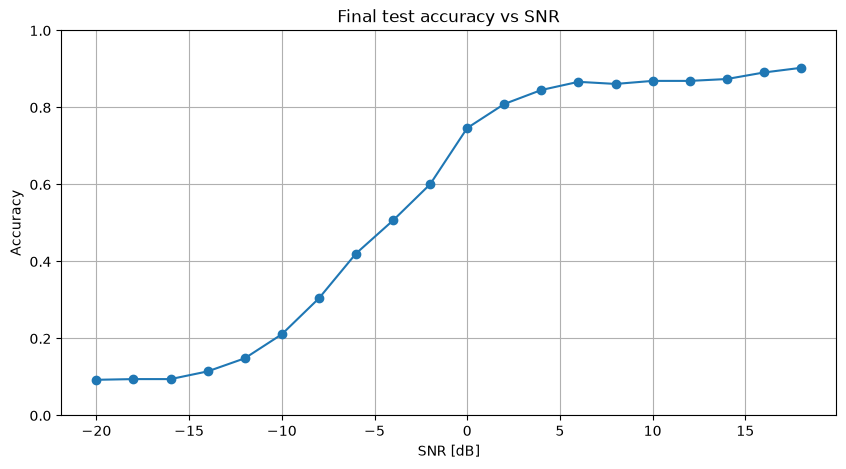

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    test_snr_results_df["snr"],
    test_snr_results_df["accuracy"],
    marker="o"
)

ax.set_title(
    "Final test accuracy vs SNR"
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True)

plt.show()

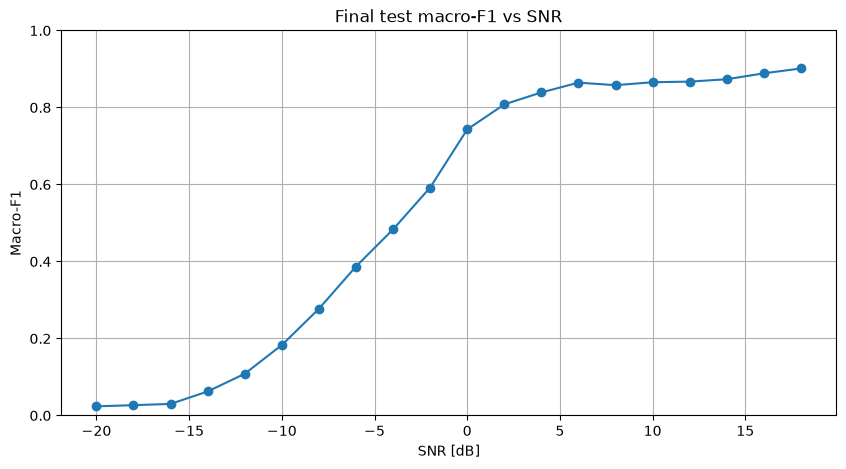

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    test_snr_results_df["snr"],
    test_snr_results_df["macro_f1"],
    marker="o"
)

ax.set_title(
    "Final test macro-F1 vs SNR"
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.grid(True)

plt.show()

In [25]:
validation_accuracy_by_snr = {
    -20: 0.0988,
    -18: 0.0964,
    -16: 0.0976,
    -14: 0.1145,
    -12: 0.1412,
    -10: 0.2103,
    -8: 0.2988,
    -6: 0.4218,
    -4: 0.5055,
    -2: 0.5921,
    0: 0.7485,
    2: 0.8170,
    4: 0.8206,
    6: 0.8552,
    8: 0.8539,
    10: 0.8612,
    12: 0.8703,
    14: 0.8612,
    16: 0.8970,
    18: 0.9127,
}

In [26]:
validation_snr_df = pd.DataFrame({
    "snr": list(
        validation_accuracy_by_snr.keys()
    ),
    "validation_accuracy": list(
        validation_accuracy_by_snr.values()
    ),
})

In [27]:
snr_comparison = test_snr_results_df.merge(
    validation_snr_df,
    on="snr"
)

snr_comparison[
    "accuracy_delta_test_minus_validation"
] = (
    snr_comparison["accuracy"]
    - snr_comparison["validation_accuracy"]
)

snr_comparison

,snr,accuracy,macro_f1,validation_accuracy,accuracy_delta_test_minus_validation
0,-20,0.092727,0.023820,0.0988,-0.006073
1,-18,0.094545,0.026820,0.0964,-0.001855
2,-16,0.094545,0.030082,0.0976,-0.003055
3,-14,0.114545,0.062407,0.1145,0.000045
4,-12,0.148485,0.108372,0.1412,0.007285
5,-10,0.210909,0.182998,0.2103,0.000609
6,-8,0.304242,0.277068,0.2988,0.005442
7,-6,0.420606,0.386995,0.4218,-0.001194
8,-4,0.506667,0.483387,0.5055,0.001167
9,-2,0.600606,0.592020,0.5921,0.008506


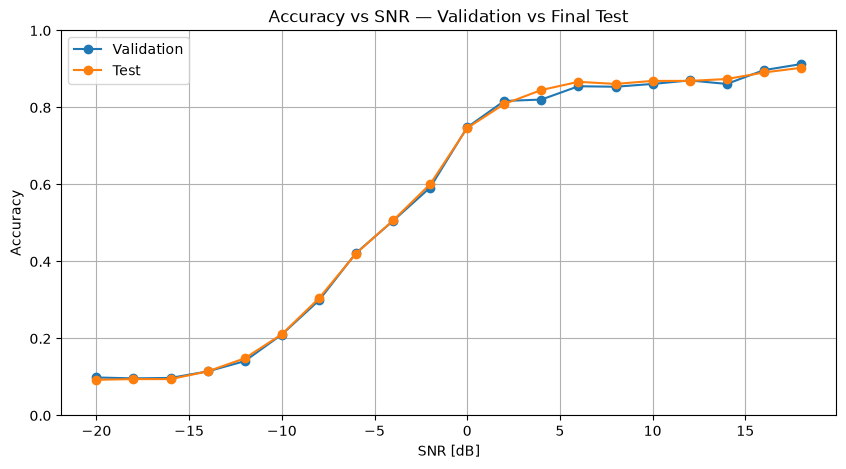

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    snr_comparison["snr"],
    snr_comparison["validation_accuracy"],
    marker="o",
    label="Validation"
)

ax.plot(
    snr_comparison["snr"],
    snr_comparison["accuracy"],
    marker="o",
    label="Test"
)

ax.set_title(
    "Accuracy vs SNR — Validation vs Final Test"
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)

ax.legend()
ax.grid(True)

plt.show()

In [29]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
)

In [30]:
classes = sorted(
    test_evaluation_df[
        "true_modulation"
    ].unique()
)

test_class_snr_results = []

for snr in sorted(
    test_evaluation_df["snr"].unique()
):

    snr_data = test_evaluation_df[
        test_evaluation_df["snr"] == snr
    ]

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            snr_data["true_modulation"],
            snr_data["predicted_modulation"],
            labels=classes,
            zero_division=0,
        )
    )

    for i, modulation in enumerate(classes):

        test_class_snr_results.append({
            "snr": snr,
            "modulation": modulation,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
        })

test_class_snr_df = pd.DataFrame(
    test_class_snr_results
)

In [31]:
test_f1_matrix = test_class_snr_df.pivot(
    index="modulation",
    columns="snr",
    values="f1"
)

test_f1_matrix.round(2)

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,0.01,0.00,0.00,0.00,0.00,0.00,0.03,0.10,0.14,0.33,0.58,0.83,0.93,0.93,0.91,0.95,0.94,0.94,0.96,0.96
AM-DSB,0.04,0.06,0.06,0.21,0.31,0.38,0.41,0.53,0.62,0.67,0.72,0.67,0.76,0.79,0.78,0.78,0.79,0.77,0.75,0.77
AM-SSB,0.17,0.17,0.17,0.18,0.20,0.25,0.33,0.61,0.95,0.96,0.95,0.97,0.94,0.95,0.95,0.94,0.96,0.95,0.95,0.96
BPSK,0.04,0.00,0.01,0.01,0.01,0.04,0.09,0.13,0.32,0.63,0.86,0.94,0.97,0.98,0.97,0.99,0.99,0.98,0.99,0.98
CPFSK,0.00,0.01,0.00,0.00,0.00,0.04,0.04,0.23,0.39,0.62,0.83,0.95,0.99,1.00,0.99,1.00,1.00,1.00,1.00,1.00
GFSK,0.00,0.00,0.01,0.00,0.02,0.03,0.19,0.48,0.71,0.79,0.93,0.95,0.95,0.96,0.97,0.97,0.97,0.99,1.00,1.00
PAM4,0.00,0.00,0.00,0.00,0.03,0.31,0.64,0.66,0.74,0.85,0.96,0.96,0.97,0.98,0.98,0.97,0.99,0.99,0.98,0.99
QAM16,0.00,0.00,0.01,0.01,0.03,0.14,0.33,0.42,0.41,0.38,0.56,0.59,0.62,0.64,0.63,0.68,0.61,0.65,0.73,0.76
QAM64,0.00,0.00,0.00,0.19,0.40,0.46,0.50,0.49,0.41,0.45,0.58,0.61,0.64,0.65,0.62,0.66,0.63,0.65,0.81,0.84


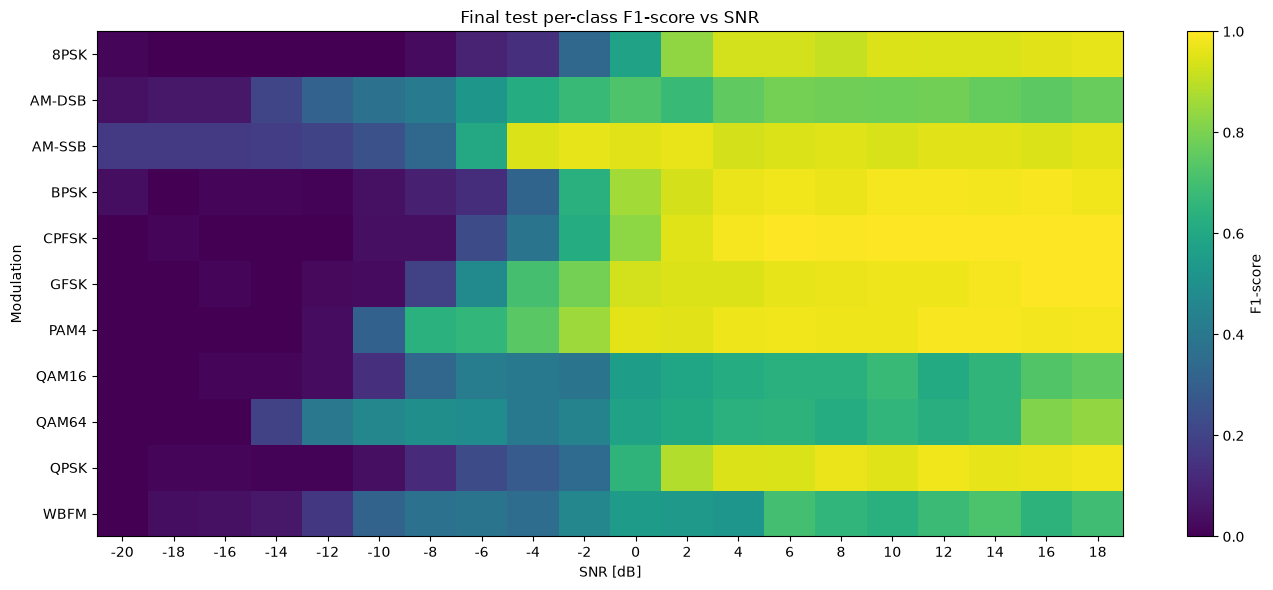

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    test_f1_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(
    range(len(test_f1_matrix.columns))
)

ax.set_xticklabels(
    test_f1_matrix.columns
)

ax.set_yticks(
    range(len(test_f1_matrix.index))
)

ax.set_yticklabels(
    test_f1_matrix.index
)

ax.set_xlabel("SNR [dB]")
ax.set_ylabel("Modulation")

ax.set_title(
    "Final test per-class F1-score vs SNR"
)

fig.colorbar(
    image,
    ax=ax,
    label="F1-score"
)

plt.tight_layout()
plt.show()

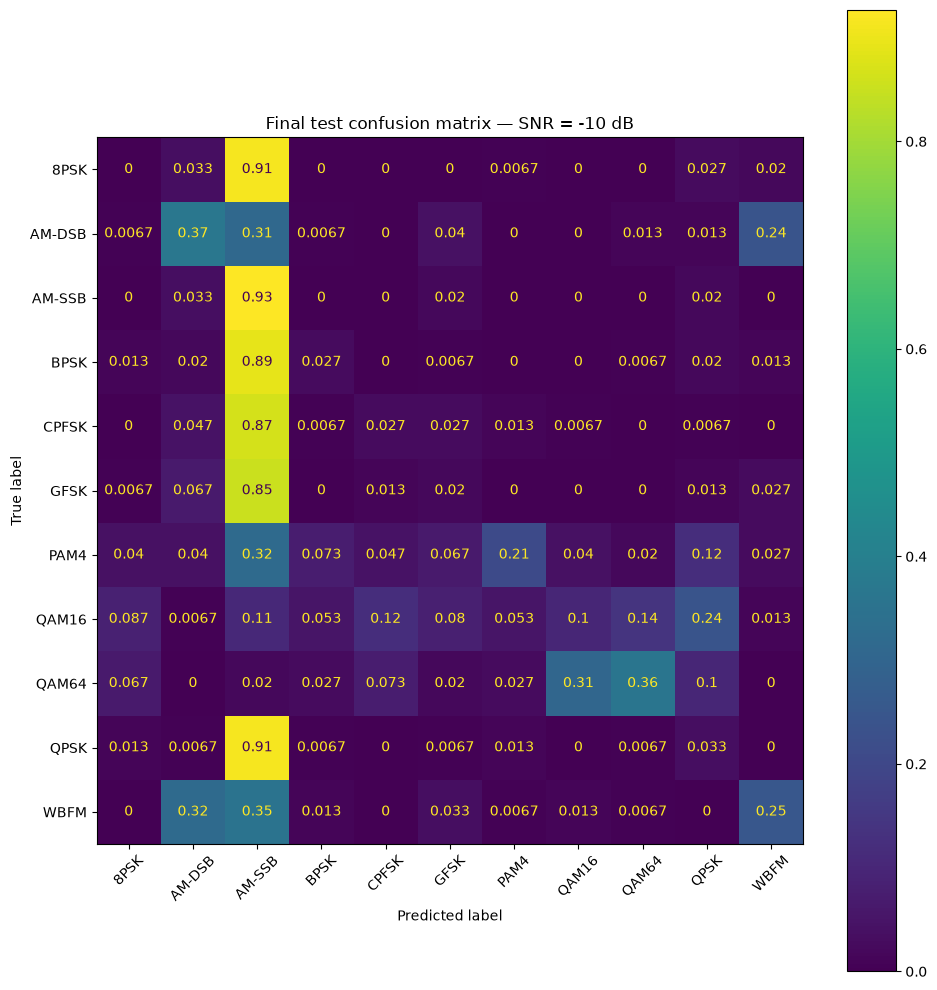

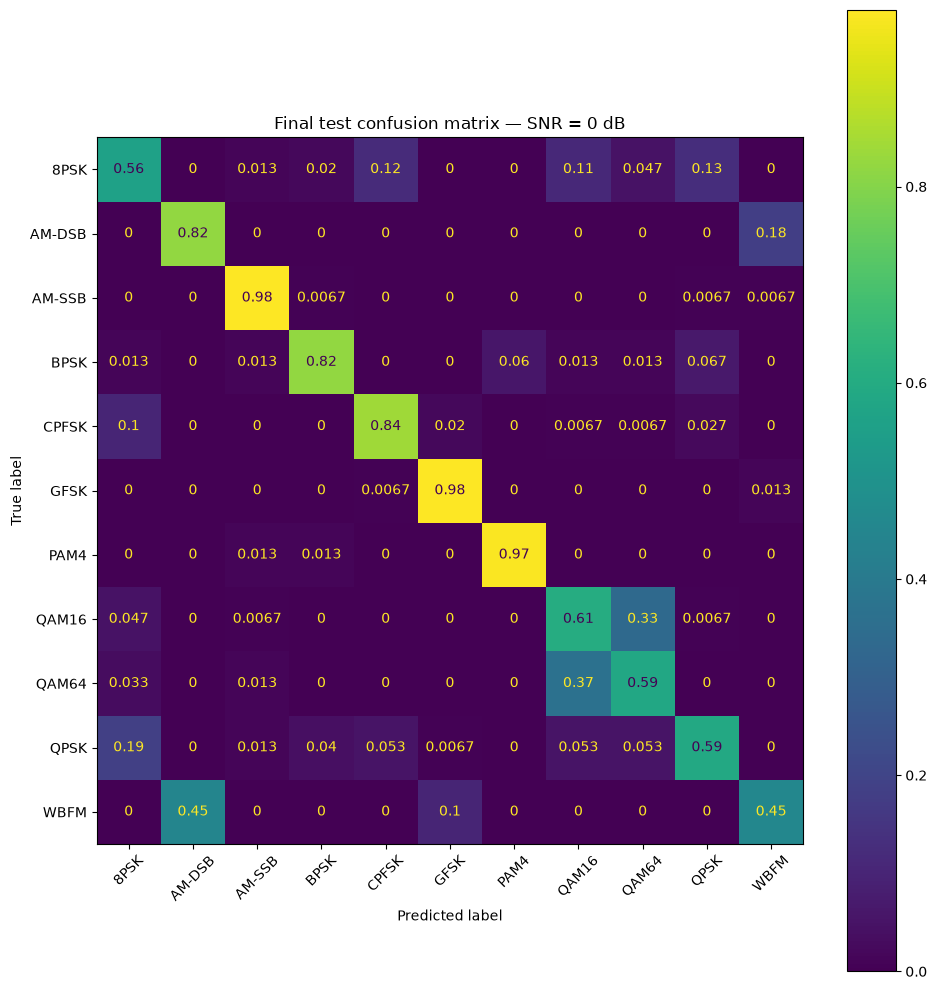

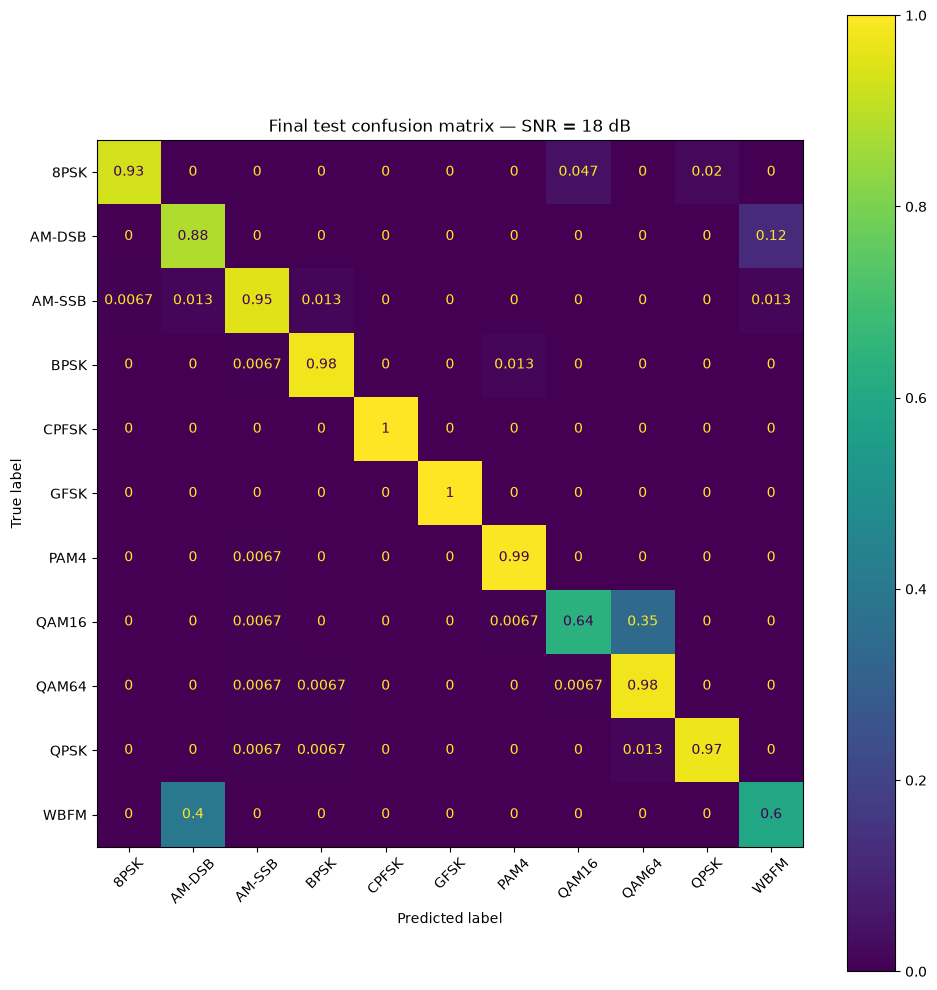

In [33]:
snr_levels = [-10, 0, 18]

for snr in snr_levels:

    snr_data = test_evaluation_df[
        test_evaluation_df["snr"] == snr
    ]

    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    ConfusionMatrixDisplay.from_predictions(
        snr_data["true_modulation"],
        snr_data["predicted_modulation"],
        normalize="true",
        xticks_rotation=45,
        ax=ax,
    )

    ax.set_title(
        f"Final test confusion matrix — "
        f"SNR = {snr} dB"
    )

    plt.tight_layout()
    plt.show()

## Final conclusions

The frozen 29-feature Random Forest achieves:

- Test accuracy: 0.5562
- Test macro-F1: 0.5786

These results are highly consistent with:

- OOF train macro-F1: 0.5765
- Validation macro-F1: 0.5762

The accuracy-vs-SNR curve on the held-out test set almost perfectly
reproduces the validation curve, confirming that the SNR-dependent
behavior generalizes.

At very low SNR, performance approaches chance level and many signals
collapse toward the AM-SSB decision region.

At medium and high SNR, temporal, spectral and angular modulation
structure becomes progressively recoverable.

The physically motivated circular_moment_4 feature successfully
generalizes to the independent test set, substantially reducing the
previous QPSK/8PSK confusion at high SNR.

The main remaining high-SNR limitations are:

- QAM16 vs QAM64
- WBFM vs AM-DSB

These limitations were investigated during development, but the tested
additional feature blocks and mixture-of-experts architecture did not
provide sufficient end-to-end improvement to justify their complexity.

The final model is therefore retained without further modification.

## 6. Export final model

The frozen Random Forest model and its exact 29-feature schema are
saved for reproducible inference and deployment.

In [34]:
import json
import joblib

In [35]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "final_rf_29_features.joblib"
METADATA_PATH = MODELS_DIR / "final_rf_29_features.json"

In [36]:
joblib.dump(
    final_rf,
    MODEL_PATH,
    compress=3
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
C:\Users\joset\Projects\snr-aware-modulation-classification\models\final_rf_29_features.joblib


In [37]:
model_metadata = {
    "model_name": "RandomForestClassifier",
    "dataset": "RadioML 2016.10A",
    "feature_set": "full_final",
    "n_features": 29,

    "feature_columns": list(
        final_feature_columns
    ),

    "hyperparameters": {
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 2,
        "random_state": 42,
        "n_jobs": -1,
    },

    "classes": [
        str(label)
        for label in final_rf.classes_
    ],

    "final_test": {
        "accuracy": float(test_accuracy),
        "macro_f1": float(test_macro_f1),
    },
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_metadata,
        f,
        indent=4
    )

print("Metadata saved to:")
print(METADATA_PATH)

Metadata saved to:
C:\Users\joset\Projects\snr-aware-modulation-classification\models\final_rf_29_features.json


In [38]:
loaded_rf = joblib.load(
    MODEL_PATH
)

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:

    loaded_metadata = json.load(f)

print(
    "Loaded features:",
    len(
        loaded_metadata[
            "feature_columns"
        ]
    )
)

print(
    "Loaded classes:",
    loaded_rf.classes_
)

Loaded features: 29
Loaded classes: ['8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64'
 'QPSK' 'WBFM']


In [39]:
reloaded_predictions = loaded_rf.predict(
    X_test_final
)

same_predictions = np.array_equal(
    test_predictions,
    reloaded_predictions
)

print(
    "Predictions identical:",
    same_predictions
)

Predictions identical: True


In [40]:
from rfml.inference import (
    load_model_and_metadata,
    predict_modulation,
)

loaded_model, loaded_metadata = load_model_and_metadata(
    MODEL_PATH,
    METADATA_PATH,
)

test_row = test_metadata.iloc[0]

sample = radioml[
    (
        test_row["modulation"],
        int(test_row["snr"]),
    )
][
    int(test_row["array_index"])
]

result = predict_modulation(
    sample,
    loaded_model,
    loaded_metadata,
)

print("True modulation:", test_row["modulation"])
print("SNR:", test_row["snr"])
print("Prediction:", result["predicted_modulation"])
print("Confidence:", result["confidence"])

True modulation: WBFM
SNR: 0
Prediction: GFSK
Confidence: 0.5616879706278715


In [41]:
reloaded_predictions = loaded_model.predict(
    X_test_final
)

print(
    "Predictions identical:",
    np.array_equal(
        test_predictions,
        reloaded_predictions,
    )
)

Predictions identical: True
